# 物理信息神经网络可视化

## PINNs 结构

Physics-Informed Neural Networks, PINNs (物理信息神经网络)

### 网络结构

建立一个全连接神经网络

输入层: 三个神经元 时间 t 摆长 l 初始角度 $\theta_0$

隐藏层: 3 层，每层 128 个神经元，Tanh 激活函数

输出层: 一个神经元 摆角 $\theta$

## 损失函数

PINNs 的损失函数表示为:
$$
Loss(\theta) = \underbrace{\lambda_{data} \frac{1}{N_u} \sum_{i=1}^{N_u} |\hat{u}_i - u_i|^2}_{Loss_{data}} + \underbrace{\lambda_{f} \frac{1}{N_f} \sum_{j=1}^{N_f} |f(x_j, t_j)|^2}_{Loss_{physics}}
$$

# 模型1 

## 方程基础

$$\frac{d^2\theta}{dt^2} + \frac{g}{l} \sin\theta = 0$$

## 损失函数

$$
Loss_{physics} = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| \frac{\partial^2 \theta_j}{\partial t^2} + \frac{g_j}{l_j} \sin(\theta_j) \right|^2
$$

模型1 | 测试集: E:\MyGithubProject\IntuitionPhysicsProjectCode\data\test_dataset\ode_prediction_test.csv
  MAE (rad): 0.304065572456296   RMSE (rad): 0.3892649482616966
  checkpoint config: {'dataset_source': 'algorithm', 'physics_mode': 'nonlinear', 'train_csv': 'E:\\MyGithubProject\\IntuitionPhysicsProjectCode\\data\\raw\\algorithm_prediction_data\\ode_prediction_data.csv', 'hidden_dim': 128, 'n_hidden': 3}


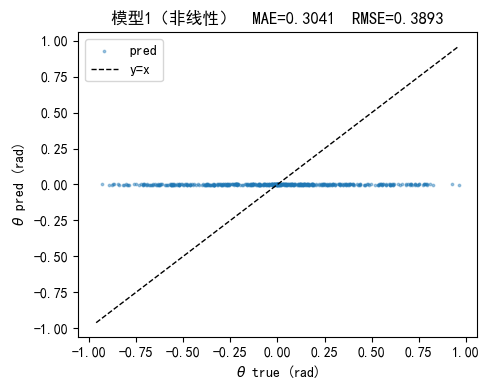

In [1]:
"""模型1（非线性残差）：加载 checkpoint、在测试集上评估并可视化。"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from intuition_physics_ml.models.pinns.pinns_input_normalizer import PinnsInputNormalizer
from intuition_physics_ml.models.pinns.pinns_net import PendulumPINN
from intuition_physics_ml.ode_prediction_data import default_ode_prediction_test_csv_path
from intuition_physics_ml.paths import repo_root

# 解决中文显示问题
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

def _load_checkpoint(run_rel: str) -> tuple[PendulumPINN | None, dict | None, PinnsInputNormalizer | None]:
    root = repo_root()
    p = root / run_rel / "checkpoint.pt"
    if not p.is_file():
        return None, None, None
    try:
        ck = torch.load(p, map_location="cpu", weights_only=True)
    except TypeError:
        ck = torch.load(p, map_location="cpu")
    meta = ck.get("config", {})
    net = PendulumPINN(
        hidden_dim=int(meta.get("hidden_dim", 128)),
        n_hidden=int(meta.get("n_hidden", 3)),
    )
    net.load_state_dict(ck["model_state_dict"])
    net.eval()
    raw_n = ck.get("pinns_input_norm")
    norm = PinnsInputNormalizer.from_dict(raw_n) if raw_n is not None else None
    return net, meta, norm


RUN_MODEL01 = "artifacts/pinns/algorithm/pinns_run/model01"
test_path = default_ode_prediction_test_csv_path()
df_test = pd.read_csv(test_path)
y_true = df_test["theta"].to_numpy(dtype=np.float64).reshape(-1, 1)
t_col = torch.tensor(df_test["t"].values, dtype=torch.float32).reshape(-1, 1)
l_col = torch.tensor(df_test["l"].values, dtype=torch.float32).reshape(-1, 1)
th_col = torch.tensor(df_test["theta0"].values, dtype=torch.float32).reshape(-1, 1)

net1, meta1, norm1 = _load_checkpoint(RUN_MODEL01)
fig, ax = plt.subplots(figsize=(5, 4))
if net1 is None:
    ax.set_title("模型1（非线性）\n未找到 checkpoint.pt，请先训练")
    ax.text(0.5, 0.5, "无权重", ha="center", va="center", transform=ax.transAxes)
else:
    if norm1 is not None:
        X = norm1.pack(t_col, l_col, th_col)
    else:
        X = torch.tensor(df_test[["t", "l", "theta0"]].values, dtype=torch.float32)
    with torch.no_grad():
        pred1 = net1(X).numpy()
    err = pred1 - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    ax.scatter(y_true.flatten(), pred1.flatten(), s=3, alpha=0.4, label="pred")
    lim = float(max(np.abs(y_true).max(), np.abs(pred1).max()))
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="y=x")
    ax.set_xlabel(r"$\theta$ true (rad)")
    ax.set_ylabel(r"$\theta$ pred (rad)")
    ax.set_title(f"模型1（非线性）  MAE={mae:.4f}  RMSE={rmse:.4f}")
    ax.legend(loc="upper left")
    print("模型1 | 测试集:", test_path)
    print("  MAE (rad):", mae, "  RMSE (rad):", rmse)
    if meta1:
        print("  checkpoint config:", meta1)
plt.tight_layout()
plt.show()


# 模型2

## 方程基础

小角度近似 ($\theta_0 < 5^\circ$)

$$
\theta(t) = \theta_0 \cos\left(\sqrt{\frac{g}{l}}\, t\right)
$$

## 损失函数

$$
Loss_{physics} = \frac{1}{N_f} \sum_{j=1}^{N_f} \left| \frac{\partial^2 \theta_j}{\partial t^2} + \frac{g_j}{l_j} \theta_j \right|^2
$$


模型2 | 测试集: E:\MyGithubProject\IntuitionPhysicsProjectCode\data\test_dataset\ode_prediction_test.csv
  MAE (rad): 0.30406552975370077   RMSE (rad): 0.3892646381502364
  checkpoint config: {'dataset_source': 'algorithm', 'physics_mode': 'linear', 'train_csv': 'E:\\MyGithubProject\\IntuitionPhysicsProjectCode\\data\\raw\\algorithm_prediction_data\\ode_prediction_data.csv', 'hidden_dim': 128, 'n_hidden': 3}


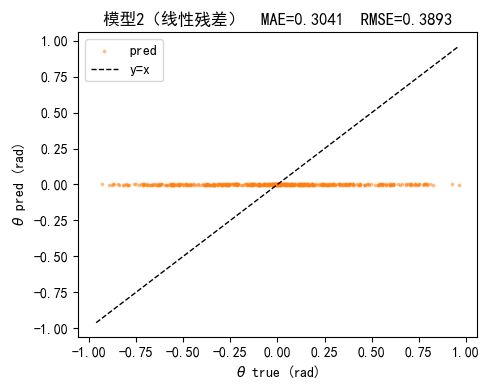

In [2]:
"""模型2（线性残差）：加载 checkpoint、在测试集上评估并可视化。"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from intuition_physics_ml.models.pinns.pinns_input_normalizer import PinnsInputNormalizer
from intuition_physics_ml.models.pinns.pinns_net import PendulumPINN
from intuition_physics_ml.ode_prediction_data import default_ode_prediction_test_csv_path
from intuition_physics_ml.paths import repo_root

# 解决中文显示问题
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

def _load_checkpoint(run_rel: str) -> tuple[PendulumPINN | None, dict | None, PinnsInputNormalizer | None]:
    root = repo_root()
    p = root / run_rel / "checkpoint.pt"
    if not p.is_file():
        return None, None, None
    try:
        ck = torch.load(p, map_location="cpu", weights_only=True)
    except TypeError:
        ck = torch.load(p, map_location="cpu")
    meta = ck.get("config", {})
    net = PendulumPINN(
        hidden_dim=int(meta.get("hidden_dim", 128)),
        n_hidden=int(meta.get("n_hidden", 3)),
    )
    net.load_state_dict(ck["model_state_dict"])
    net.eval()
    raw_n = ck.get("pinns_input_norm")
    norm = PinnsInputNormalizer.from_dict(raw_n) if raw_n is not None else None
    return net, meta, norm


RUN_MODEL02 = "artifacts/pinns/algorithm/pinns_run/model02"
test_path = default_ode_prediction_test_csv_path()
df_test = pd.read_csv(test_path)
y_true = df_test["theta"].to_numpy(dtype=np.float64).reshape(-1, 1)
t_col = torch.tensor(df_test["t"].values, dtype=torch.float32).reshape(-1, 1)
l_col = torch.tensor(df_test["l"].values, dtype=torch.float32).reshape(-1, 1)
th_col = torch.tensor(df_test["theta0"].values, dtype=torch.float32).reshape(-1, 1)

net2, meta2, norm2 = _load_checkpoint(RUN_MODEL02)
fig, ax = plt.subplots(figsize=(5, 4))
if net2 is None:
    ax.set_title("模型2（线性残差）\n未找到 checkpoint.pt，请先训练")
    ax.text(0.5, 0.5, "无权重", ha="center", va="center", transform=ax.transAxes)
else:
    if norm2 is not None:
        X = norm2.pack(t_col, l_col, th_col)
    else:
        X = torch.tensor(df_test[["t", "l", "theta0"]].values, dtype=torch.float32)
    with torch.no_grad():
        pred2 = net2(X).numpy()
    err = pred2 - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    ax.scatter(y_true.flatten(), pred2.flatten(), s=3, alpha=0.4, color="C1", label="pred")
    lim = float(max(np.abs(y_true).max(), np.abs(pred2).max()))
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="y=x")
    ax.set_xlabel(r"$\theta$ true (rad)")
    ax.set_ylabel(r"$\theta$ pred (rad)")
    ax.set_title(f"模型2（线性残差）  MAE={mae:.4f}  RMSE={rmse:.4f}")
    ax.legend(loc="upper left")
    print("模型2 | 测试集:", test_path)
    print("  MAE (rad):", mae, "  RMSE (rad):", rmse)
    if meta2:
        print("  checkpoint config:", meta2)
plt.tight_layout()
plt.show()


## 训练命令（仓库根目录）

```bash
python -m intuition_physics_ml.cli_pinns --config configs/pinns/algorithm_model01.yaml
python -m intuition_physics_ml.cli_pinns --config configs/pinns/algorithm_model02.yaml
```

人类数据就绪后，将 YAML 中 `dataset_source` 改为 `human`，`train_csv` 指向 `data/raw/human_prediction_data/` 下宽表；产物在 `artifacts/pinns/human/pinns_run/model01`（或 `model02`）。

## 模型对比

在同一测试集上并排查看两个模型的预测–真值散点，并对比 MAE / RMSE（柱状图）。运行前请先执行上方「模型1」「模型2」单元格或确保本格内能加载到两份权重。


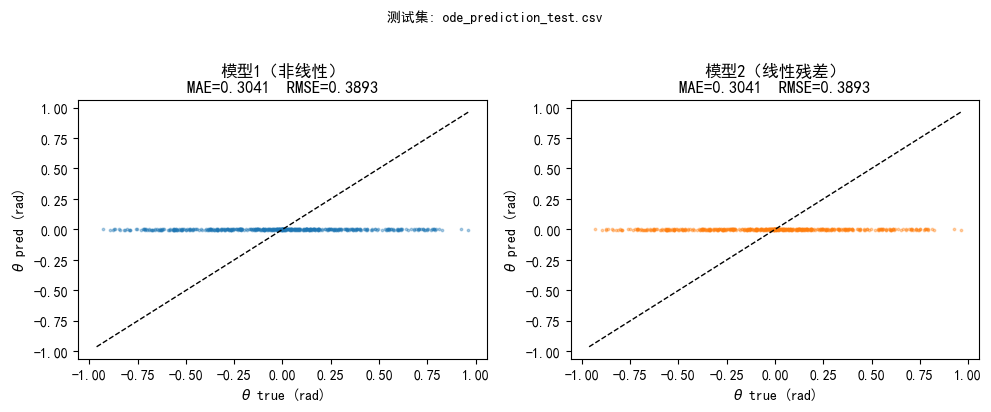

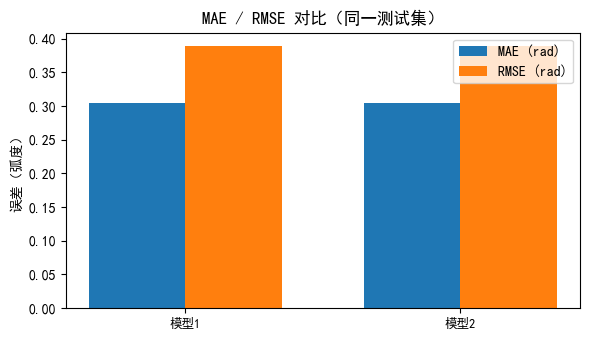

对比汇总: {'模型1（非线性）': (0.304065572456296, 0.3892649482616966), '模型2（线性残差）': (0.30406552975370077, 0.3892646381502364)}


In [3]:
"""并排对比模型1与模型2；若缺 checkpoint 则对应子图留空。"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from intuition_physics_ml.models.pinns.pinns_input_normalizer import PinnsInputNormalizer
from intuition_physics_ml.models.pinns.pinns_net import PendulumPINN
from intuition_physics_ml.ode_prediction_data import default_ode_prediction_test_csv_path
from intuition_physics_ml.paths import repo_root

# 解决中文显示问题
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

def _load_checkpoint(run_rel: str) -> tuple[PendulumPINN | None, dict | None, PinnsInputNormalizer | None]:
    root = repo_root()
    p = root / run_rel / "checkpoint.pt"
    if not p.is_file():
        return None, None, None
    try:
        ck = torch.load(p, map_location="cpu", weights_only=True)
    except TypeError:
        ck = torch.load(p, map_location="cpu")
    meta = ck.get("config", {})
    net = PendulumPINN(
        hidden_dim=int(meta.get("hidden_dim", 128)),
        n_hidden=int(meta.get("n_hidden", 3)),
    )
    net.load_state_dict(ck["model_state_dict"])
    net.eval()
    raw_n = ck.get("pinns_input_norm")
    norm = PinnsInputNormalizer.from_dict(raw_n) if raw_n is not None else None
    return net, meta, norm


RUN01 = "artifacts/pinns/algorithm/pinns_run/model01"
RUN02 = "artifacts/pinns/algorithm/pinns_run/model02"

test_path = default_ode_prediction_test_csv_path()
df_test = pd.read_csv(test_path)
y_true = df_test["theta"].to_numpy(dtype=np.float64).reshape(-1, 1)
t_col = torch.tensor(df_test["t"].values, dtype=torch.float32).reshape(-1, 1)
l_col = torch.tensor(df_test["l"].values, dtype=torch.float32).reshape(-1, 1)
th_col = torch.tensor(df_test["theta0"].values, dtype=torch.float32).reshape(-1, 1)

net1, _, norm1 = _load_checkpoint(RUN01)
net2, _, norm2 = _load_checkpoint(RUN02)


def _pack_inputs(norm: PinnsInputNormalizer | None) -> torch.Tensor:
    if norm is not None:
        return norm.pack(t_col, l_col, th_col)
    return torch.tensor(df_test[["t", "l", "theta0"]].values, dtype=torch.float32)

metrics: dict[str, tuple[float, float]] = {}
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
titles = [
    ("模型1（非线性）", net1, norm1, "C0"),
    ("模型2（线性残差）", net2, norm2, "C1"),
]

for ax, (title, net, norm, color) in zip(axes, titles):
    if net is None:
        ax.set_title(f"{title}\n(无 checkpoint)")
        ax.text(0.5, 0.5, "请先训练", ha="center", va="center", transform=ax.transAxes)
        continue
    X_in = _pack_inputs(norm)
    with torch.no_grad():
        pred = net(X_in).numpy()
    err = pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    metrics[title] = (mae, rmse)
    ax.scatter(y_true.flatten(), pred.flatten(), s=3, alpha=0.35, color=color)
    lim = float(max(np.abs(y_true).max(), np.abs(pred).max()))
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
    ax.set_xlabel(r"$\theta$ true (rad)")
    ax.set_ylabel(r"$\theta$ pred (rad)")
    ax.set_title(f"{title}\nMAE={mae:.4f}  RMSE={rmse:.4f}")

plt.suptitle(f"测试集: {test_path.name}", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

if metrics:
    order = ["模型1（非线性）", "模型2（线性残差）"]
    labels_short = ["模型1", "模型2"]
    maes, rmses, labels = [], [], []
    for lab_s, lab_f in zip(labels_short, order):
        if lab_f in metrics:
            mae, rmse = metrics[lab_f]
            maes.append(mae)
            rmses.append(rmse)
            labels.append(lab_s)
    x = np.arange(len(labels))
    w = 0.35
    fig2, axb = plt.subplots(figsize=(6, 3.5))
    axb.bar(x - w / 2, maes, width=w, label="MAE (rad)")
    axb.bar(x + w / 2, rmses, width=w, label="RMSE (rad)")
    axb.set_xticks(x)
    axb.set_xticklabels(labels, fontsize=9)
    axb.set_ylabel("误差（弧度）")
    axb.set_title("MAE / RMSE 对比（同一测试集）")
    axb.legend()
    plt.tight_layout()
    plt.show()

print("对比汇总:", metrics if metrics else "（无可用权重）")
